In [1]:
!nvidia-smi

Sun May 17 14:18:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.4 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!ls "/content/drive/MyDrive/data/DATA_CLEAN"

images	labels


In [6]:
!cp -r "/content/drive/MyDrive/data/DATA_CLEAN" /content/DATA_CLEAN
!ls /content/DATA_CLEAN

images	labels


In [7]:
import re
import shutil
from pathlib import Path

DATA_ROOT = Path("/content/DATA_CLEAN")
IMAGES_DIR = DATA_ROOT / "images"
LABELS_DIR = DATA_ROOT / "labels"

# Handle possible double-nesting (safe no-op if not nested)
if (IMAGES_DIR / "images").exists():
    IMAGES_DIR = IMAGES_DIR / "images"
if (LABELS_DIR / "labels").exists():
    LABELS_DIR = LABELS_DIR / "labels"

print(f"Images from: {IMAGES_DIR}")
print(f"Labels from: {LABELS_DIR}")

# Detect (N) duplicate suffix
img_dup = re.compile(r"\(\d+\)$")
lbl_dup = re.compile(r"\(\d+\)\.txt$")

# Drop label duplicates, keep originals only
image_files = list(IMAGES_DIR.glob("*.jpg"))
label_files = [f for f in LABELS_DIR.glob("*.txt") if not lbl_dup.search(f.name)]
label_stems = {f.stem for f in label_files}

# For each image: skip (N) duplicates, skip already-seen names, keep if it has a matching label
matched = []
seen = set()
for img in image_files:
    if img_dup.search(img.stem):
        continue
    if img.stem in seen:
        continue
    if img.stem in label_stems:
        matched.append((img, LABELS_DIR / f"{img.stem}.txt"))
        seen.add(img.stem)

print(f"Matched image-label pairs: {len(matched)}")

# Build clean folder structure
CLEAN = Path("/content/clean")
if CLEAN.exists():
    shutil.rmtree(CLEAN)
(CLEAN / "images").mkdir(parents=True)
(CLEAN / "labels").mkdir(parents=True)

for img_path, label_path in matched:
    shutil.copy2(img_path, CLEAN / "images" / img_path.name)
    shutil.copy2(label_path, CLEAN / "labels" / label_path.name)

n_imgs = len(list((CLEAN / "images").iterdir()))
n_lbls = len(list((CLEAN / "labels").iterdir()))
print(f"Clean dataset built: {n_imgs} images, {n_lbls} labels")

Images from: /content/DATA_CLEAN/images
Labels from: /content/DATA_CLEAN/labels
Matched image-label pairs: 176
Clean dataset built: 176 images, 176 labels


## Task 1 — Dataset Inspection

### 1.1 Counts and label–image matching

The raw dataset had **248 images** and **4,535 label files** — a large mismatch. Investigation revealed two issues:

- **1,087 label files** had a Windows-style `(N)` suffix (e.g. `name(1).txt`) — these were verified byte-identical to their unsuffixed originals, so they are redundant download artifacts.
- **72 of 248 images** also had `(N)` suffixes (duplicate downloads).
- After deduplicating both folders, only **176 images** had a matching original label. The remaining 3,272 "original" labels reference images that aren't in the folder.

The cleanup cell above built `/content/clean/` containing only the 176 matched, deduplicated image–label pairs. All analysis from here uses that clean set.

Clean images: 176
Clean labels: 176
Every image has a matching label: True

Class IDs and object counts:
  class 0: 207 objects

Total bounding boxes: 207


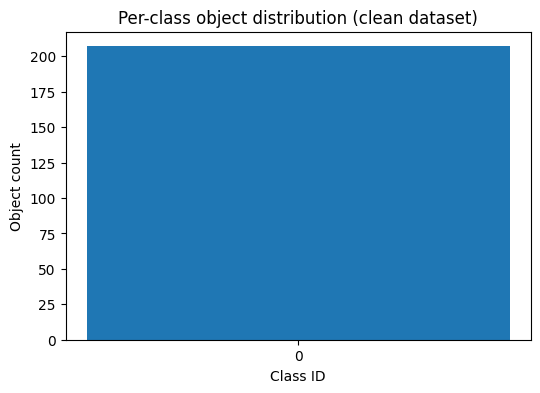

In [8]:
from collections import Counter
import matplotlib.pyplot as plt

CLEAN_IMAGES = Path("/content/clean/images")
CLEAN_LABELS = Path("/content/clean/labels")

# Re-verify after cleanup
n_imgs = len(list(CLEAN_IMAGES.glob("*.jpg")))
n_lbls = len(list(CLEAN_LABELS.glob("*.txt")))
print(f"Clean images: {n_imgs}")
print(f"Clean labels: {n_lbls}")
print(f"Every image has a matching label: {n_imgs == n_lbls}")
print()

# Count class IDs across all bounding boxes
class_counts = Counter()
for lbl in CLEAN_LABELS.glob("*.txt"):
    for line in lbl.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            class_counts[int(parts[0])] += 1

print("Class IDs and object counts:")
for cid, count in sorted(class_counts.items()):
    print(f"  class {cid}: {count} objects")
print(f"\nTotal bounding boxes: {sum(class_counts.values())}")

# Bar chart
plt.figure(figsize=(6, 4))
plt.bar([str(c) for c in sorted(class_counts)],
        [class_counts[c] for c in sorted(class_counts)])
plt.xlabel("Class ID")
plt.ylabel("Object count")
plt.title("Per-class object distribution (clean dataset)")
plt.show()

In [9]:
import random
from PIL import Image
import numpy as np

random.seed(42)
sample = random.sample(list(CLEAN_IMAGES.glob("*.jpg")), min(100, n_imgs))

widths, heights = [], []
for p in sample:
    with Image.open(p) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Inspected {len(sample)} random images\n")
print("Width  — min: {}, max: {}, mean: {:.0f}".format(min(widths), max(widths), np.mean(widths)))
print("Height — min: {}, max: {}, mean: {:.0f}".format(min(heights), max(heights), np.mean(heights)))

Inspected 100 random images

Width  — min: 640, max: 6016, mean: 2660
Height — min: 640, max: 7500, mean: 2072


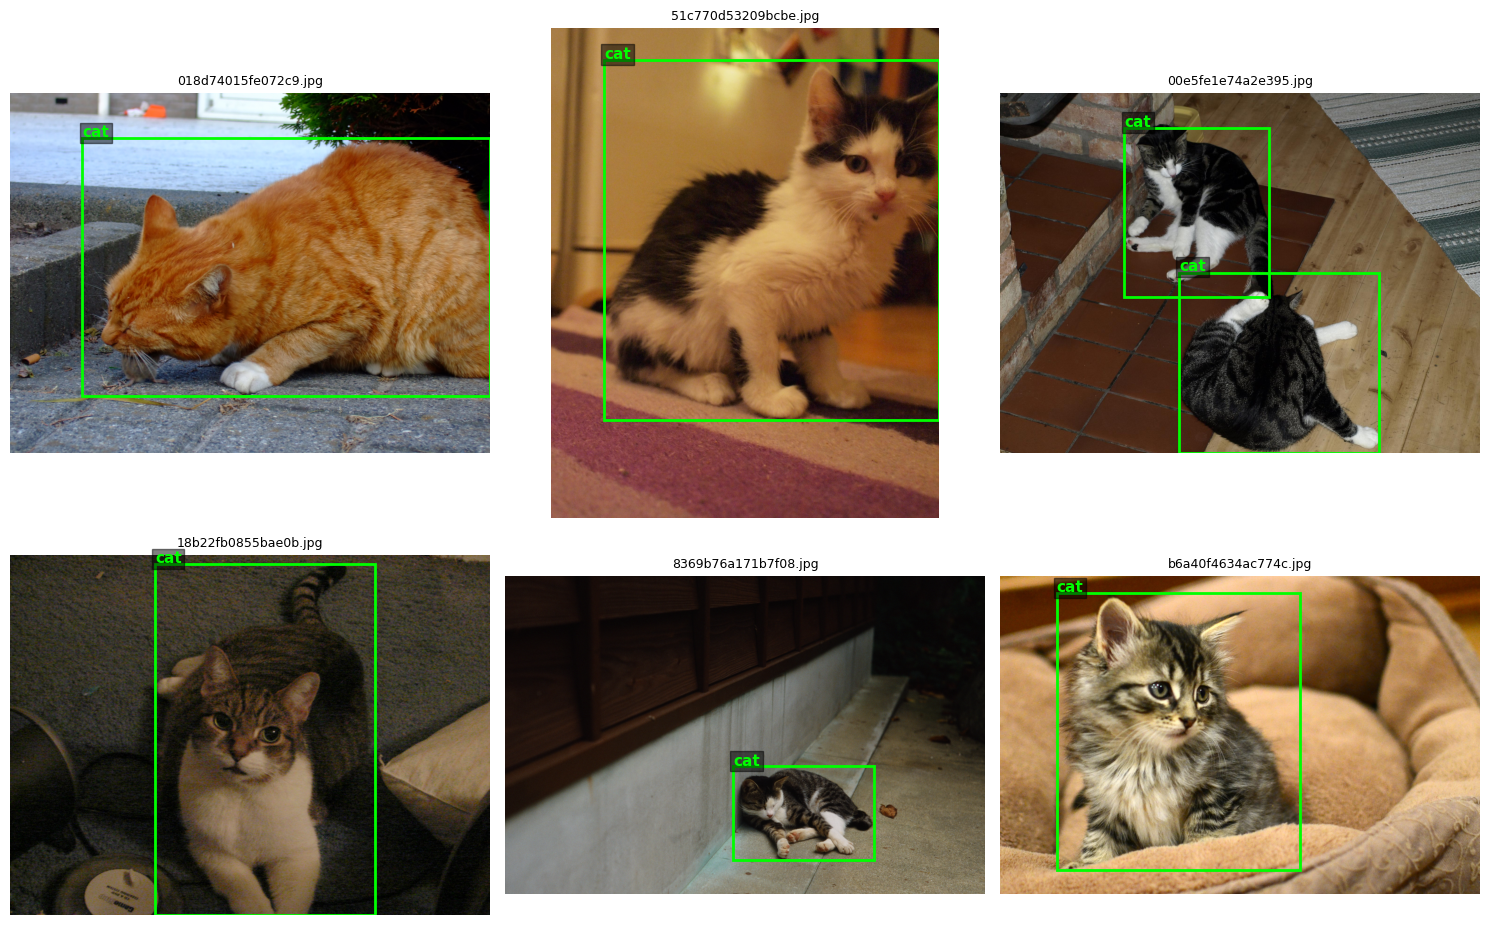

In [10]:
import matplotlib.patches as patches

CLASS_NAMES = {0: "cat"}

def draw_yolo_boxes(ax, img_path, label_path):
    img = Image.open(img_path)
    ax.imshow(img)
    W, H = img.size
    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            cid, cx, cy, bw, bh = map(float, line.split())
            x = (cx - bw/2) * W
            y = (cy - bh/2) * H
            w = bw * W
            h = bh * H
            rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                      edgecolor="lime", facecolor="none")
            ax.add_patch(rect)
            ax.text(x, y - 5, CLASS_NAMES.get(int(cid), str(int(cid))),
                    color="lime", fontsize=11, weight="bold",
                    bbox=dict(facecolor="black", alpha=0.5, pad=2))
    ax.set_title(img_path.name[:20], fontsize=9)
    ax.axis("off")

random.seed(42)
samples = random.sample(list(CLEAN_IMAGES.glob("*.jpg")), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flatten(), samples):
    lbl_path = CLEAN_LABELS / f"{img_path.stem}.txt"
    draw_yolo_boxes(ax, img_path, lbl_path)
plt.tight_layout()
plt.show()

## Task 2 — Train / Val / Test Splits

Splitting 176 clean image–label pairs into 70 / 15 / 15 using a fixed seed (42) for reproducibility. With such a small dataset, the absolute sizes are modest — ~123 train, ~26 val, ~27 test — but adequate for fine-tuning a COCO-pretrained model.

In [11]:
import random
import yaml
from pathlib import Path

CLEAN = Path("/content/clean")

random.seed(42)
images = sorted(CLEAN.glob("images/*.jpg"))
random.shuffle(images)

n = len(images)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train = images[:n_train]
val   = images[n_train:n_train + n_val]
test  = images[n_train + n_val:]

print(f"Train: {len(train)}")
print(f"Val:   {len(val)}")
print(f"Test:  {len(test)}")
print(f"Total: {len(train) + len(val) + len(test)}")

# Write absolute paths to split files
for name, files in [("train", train), ("val", val), ("test", test)]:
    (CLEAN / f"{name}.txt").write_text("\n".join(str(f) for f in files))

# Sanity check
print("\nFirst 3 train paths:")
for p in train[:3]:
    print(f"  {p}")

Train: 123
Val:   26
Test:  27
Total: 176

First 3 train paths:
  /content/clean/images/981a4f431612da85.jpg
  /content/clean/images/0c809b2801160d2e.jpg
  /content/clean/images/03d100a28a84bac5.jpg


In [12]:
  data_config = {
    "path": str(CLEAN),
    "train": "train.txt",
    "val": "val.txt",
    "test": "test.txt",
    "names": {0: "cat"},
}
with open("/content/data.yaml", "w") as f:
    yaml.dump(data_config, f, sort_keys=False)

# Verify by printing back
print(open("/content/data.yaml").read())

path: /content/clean
train: train.txt
val: val.txt
test: test.txt
names:
  0: cat



## Task 3 — Variant Choice and Training

**Variant chosen: `yolo26n`** (nano, 2.4M parameters).

I picked `yolo26n` for three reasons. First, my cleaned dataset contains only 176 image-label pairs — well below the 1–2k threshold where `yolo26s` becomes worthwhile, and a larger model would overfit faster on so few samples. Second, although Colab's T4 GPU could comfortably train `yolo26s` or `yolo26m`, `n` trains in minutes which gives me room to iterate before next week's improvement assessment. Third, the smaller checkpoint (~6 MB) will be trivial to export to ONNX and ship in next week's Docker container.

In [13]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")
results = model.train(
    data="/content/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    project="runs",
    name="cats_v1",
    seed=42,
    device=0,
    patience=50,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=

In [14]:
!cp /content/runs/detect/runs/cats_v1/weights/best.pt "/content/drive/MyDrive/yolo26_cats_best.pt"
!cp /content/runs/detect/runs/cats_v1/weights/last.pt "/content/drive/MyDrive/yolo26_cats_last.pt"
!cp /content/runs/detect/runs/cats_v1/results.png "/content/drive/MyDrive/yolo26_cats_results.png"
!cp /content/runs/detect/runs/cats_v1/results.csv "/content/drive/MyDrive/yolo26_cats_results.csv"
!ls -la "/content/drive/MyDrive/" | grep yolo26

-rw------- 1 root root 5384005 May 17 14:44 yolo26_cats_best.pt
-rw------- 1 root root 5384005 May 17 14:44 yolo26_cats_last.pt
-rw------- 1 root root    3692 May 17 14:44 yolo26_cats_results.csv
-rw------- 1 root root  324107 May 17 14:44 yolo26_cats_results.png


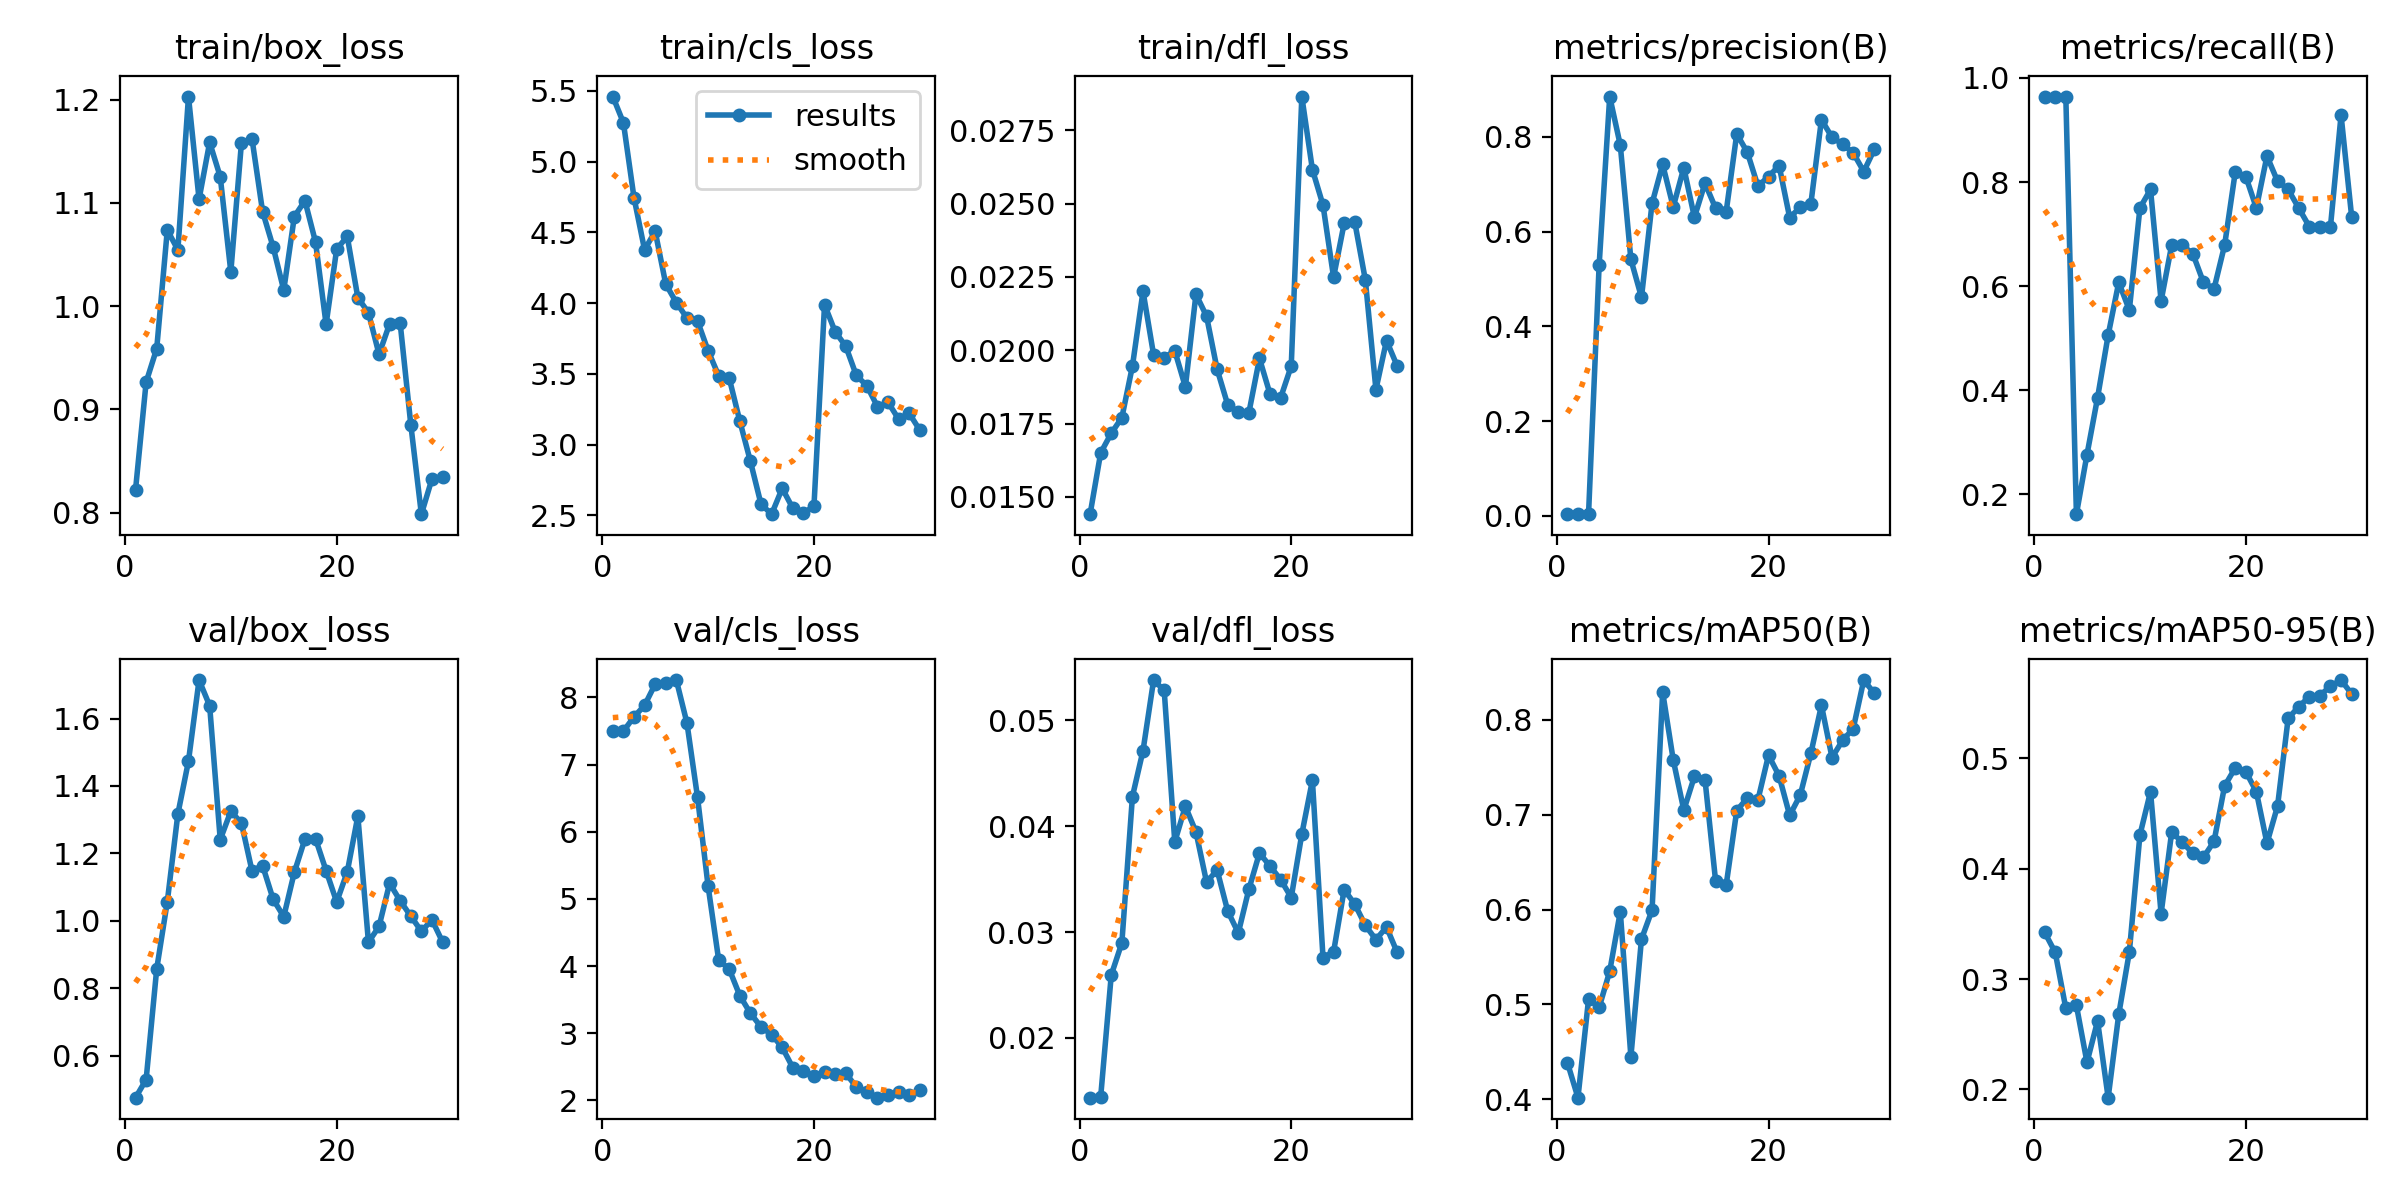

In [15]:
from IPython.display import Image as IPImage
IPImage("/content/runs/detect/runs/cats_v1/results.png")

### Task 3 results — Training summary

**Training completed:** 30 epochs in 5.3 minutes on Colab T4 GPU.

**Best validation metrics (epoch 29):**
| Metric | Value |
|---|---|
| mAP@0.5 | 0.843 |
| mAP@0.5:0.95 | 0.572 |
| Precision | 0.733 |
| Recall | 0.929 |

**Training dynamics:**
- mAP@0.5 was already 0.83 by epoch 10 (rapid convergence thanks to COCO pretraining — the base model already "knew" cats from its 80-class COCO training)
- The metric bounced between 0.62 and 0.84 from epochs 11–24 due to variance from a small (26-image) validation set
- Mosaic augmentation was disabled for the final 10 epochs (`close_mosaic=10` default), which briefly caused cls_loss to spike but ultimately tightened the model
- Best mAP came at the final epoch — the model was still improving, suggesting **no overfitting**

**Reflection on variant choice:** `yolo26n` was the right call. With 176 images, a larger model would have overfit faster, and the smooth monotonic trend in mAP@0.5:0.95 (0.34 → 0.57) over 30 epochs suggests `n` had appropriate capacity. For next week's improvement assessment, I'd consider either (a) more epochs with the same model, or (b) trying `yolo26s` on a cleaner/larger version of the dataset.

## Task 4 — Test Set Evaluation

Evaluating the best checkpoint (epoch 29) on the held-out test split of 27 images.

In [16]:
metrics = model.val(data="/content/data.yaml", split="test")
print()
print("Test set metrics:")
print(f"  mAP@0.5      : {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"  Precision    : {metrics.box.mp:.4f}")
print(f"  Recall       : {metrics.box.mr:.4f}")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2689.6±652.4 MB/s, size: 2750.4 KB)
val: Scanning /content/clean/labels... 27 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 27/27 1.3Kit/s 0.0s
val: New cache created: /content/clean/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6s/it 3.1s
                   all         27         32      0.818      0.656      0.712      0.498
Speed: 5.0ms preprocess, 23.9ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val

Test set metrics:
  mAP@0.5      : 0.7117
  mAP@0.5:0.95 : 0.4985
  Precision    : 0.8179
  Recall       : 0.6562


### Test set results

| Metric | Value |
|---|---|
| mAP@0.5      | 0.7117 |
| mAP@0.5:0.95 | 0.4985 |
| Mean precision | 0.8179 |
| Mean recall    | 0.6562 |

The test mAP@0.5 (0.71) is noticeably lower than the validation mAP@0.5 (0.84) — a 13-point gap. This is not overfitting in the training-dynamics sense (the loss curves never diverged), but rather the high variance you get when evaluating on only ~27 images. Recall dropped sharply (0.93 → 0.66), while precision actually rose (0.73 → 0.82): the model became conservative on the test split, missing some real cats but rarely boxing non-cats. With a larger held-out set, the gap would likely shrink.

## Task 5 — Visualising Predictions

Running the trained `best.pt` model on 6 random test images. For 3 of them, ground-truth boxes are also drawn (in green) alongside the predictions (in red) to show agreement and disagreement. Finally, a separate cell hunts the test set for clear failure cases (false positives or false negatives) and shows them with commentary.

In [17]:
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO

# Reload the BEST trained model from saved checkpoint
best_model = YOLO("/content/runs/detect/runs/cats_v1/weights/best.pt")

# Read test image paths from the split file
TEST_FILE = Path("/content/clean/test.txt")
test_images = [Path(p) for p in TEST_FILE.read_text().strip().splitlines()]

random.seed(7)  # different seed so visualisation isn't biased by train shuffle
samples = random.sample(test_images, 6)
print(f"Selected 6 test images:")
for p in samples:
    print(f"  {p.name}")

Selected 6 test images:
  2a634d069f739326.jpg
  bfd4ec0cf47b3877.jpg
  086a5517be51e117.jpg
  0c10d1823e5be0aa.jpg
  632de22336cd3d04.jpg
  2850487383ea935f.jpg


In [18]:
def draw_predictions_and_gt(ax, img_path, model, show_gt=False, conf_thresh=0.25):
    """Render image with predicted boxes (red) and optionally GT boxes (green)."""
    img = Image.open(img_path)
    ax.imshow(img)
    W, H = img.size

    # === Predicted boxes (red) ===
    results = model.predict(str(img_path), conf=conf_thresh, verbose=False)
    boxes = results[0].boxes
    if boxes is not None and len(boxes) > 0:
        for box, conf, cls in zip(boxes.xyxy, boxes.conf, boxes.cls):
            x1, y1, x2, y2 = box.tolist()
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                      linewidth=2.5, edgecolor="red", facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, y1 - 8, f"cat {conf:.2f}",
                    color="white", fontsize=9, weight="bold",
                    bbox=dict(facecolor="red", alpha=0.8, pad=2))

    # === Ground-truth boxes (green) ===
    if show_gt:
        label_path = Path("/content/clean/labels") / f"{img_path.stem}.txt"
        if label_path.exists():
            for line in label_path.read_text().strip().splitlines():
                cid, cx, cy, bw, bh = map(float, line.split())
                x = (cx - bw/2) * W
                y = (cy - bh/2) * H
                rect = patches.Rectangle((x, y), bw*W, bh*H,
                                          linewidth=2.5, edgecolor="lime",
                                          facecolor="none", linestyle="--")
                ax.add_patch(rect)
                ax.text(x, y + bh*H + 14, "GT",
                        color="black", fontsize=9, weight="bold",
                        bbox=dict(facecolor="lime", alpha=0.8, pad=2))

    pred_count = len(boxes) if boxes is not None else 0
    title = f"{img_path.name[:18]} | preds: {pred_count}"
    if show_gt:
        title += " | + GT"
    ax.set_title(title, fontsize=9)
    ax.axis("off")

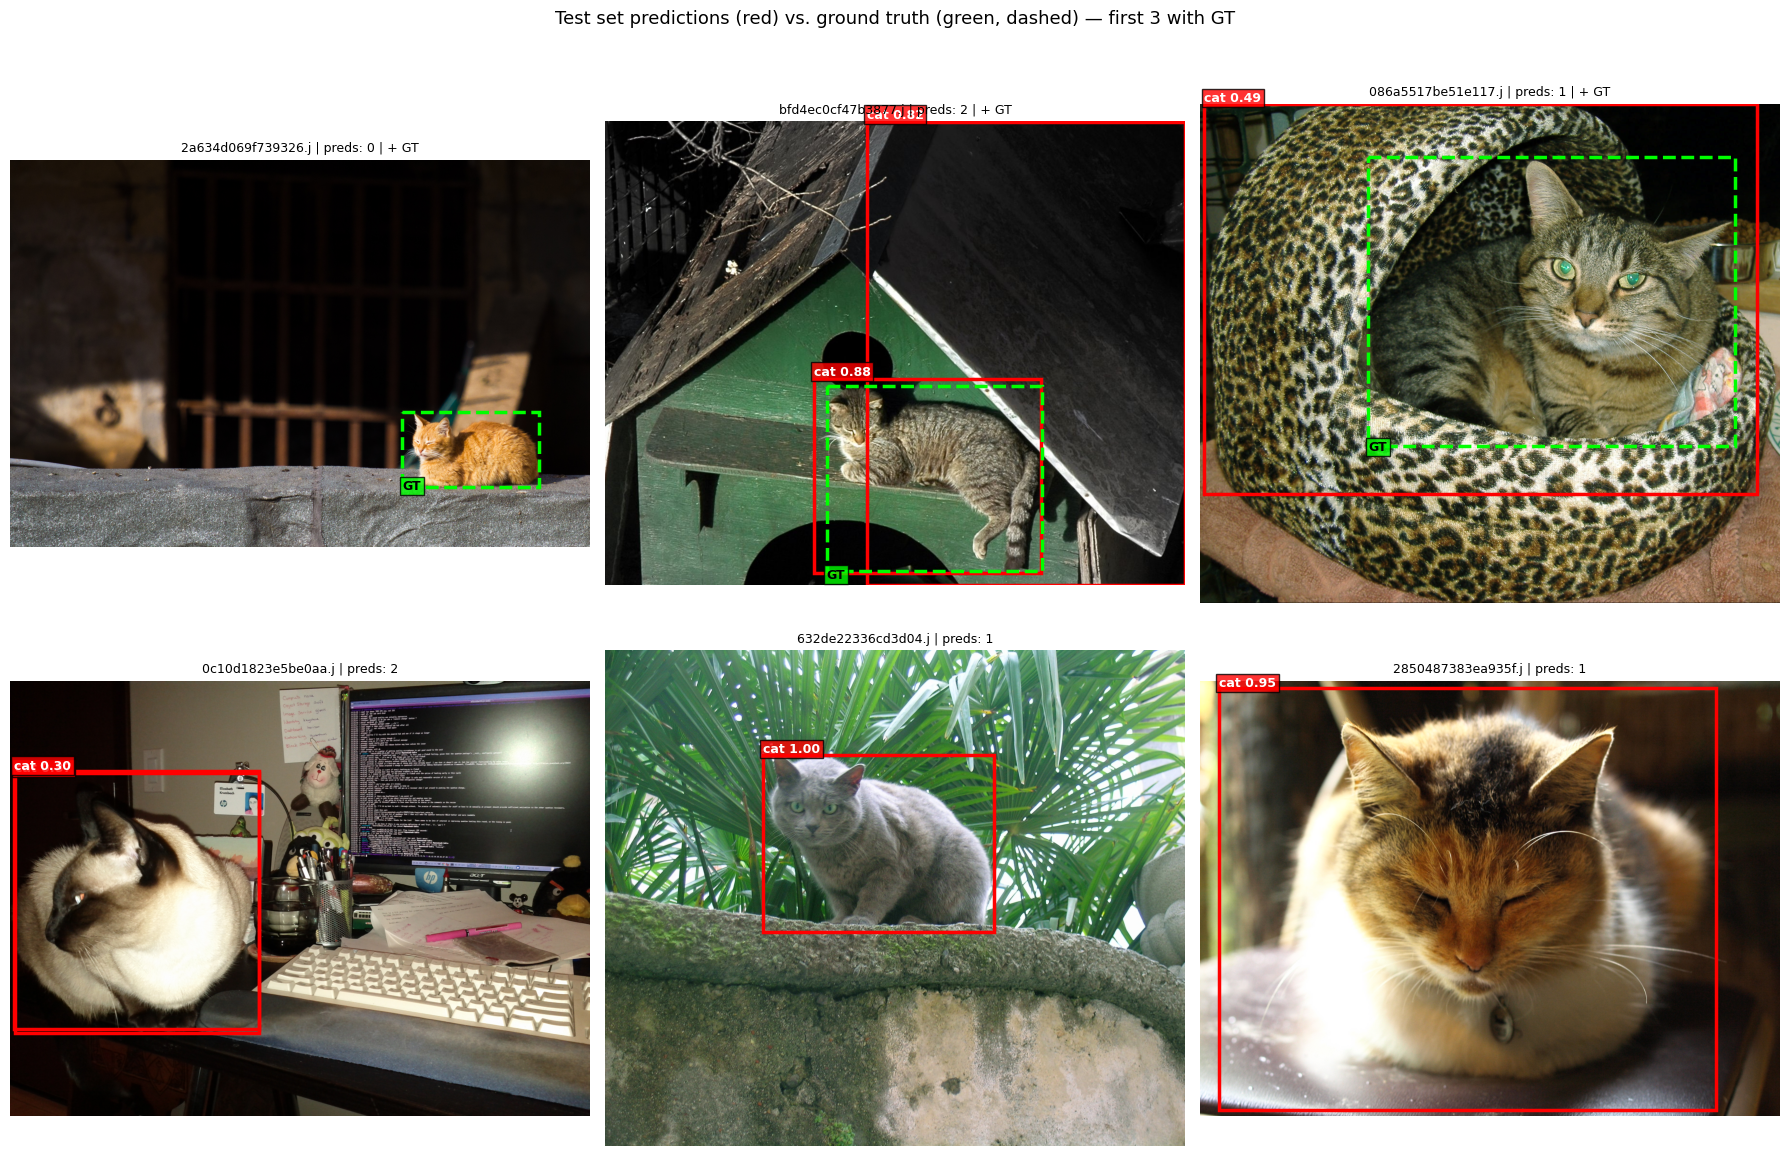

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, (ax, img_path) in enumerate(zip(axes.flatten(), samples)):
    # First 3 images: show GT boxes too. Last 3: predictions only.
    draw_predictions_and_gt(ax, img_path, best_model, show_gt=(i < 3))

plt.suptitle("Test set predictions (red) vs. ground truth (green, dashed) — first 3 with GT",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

In [20]:
# Look for failure cases: images where prediction count differs from GT count
failure_candidates = []
for img_path in test_images:
    label_path = Path("/content/clean/labels") / f"{img_path.stem}.txt"
    n_gt = len(label_path.read_text().strip().splitlines()) if label_path.exists() else 0

    results = best_model.predict(str(img_path), conf=0.25, verbose=False)
    n_pred = len(results[0].boxes) if results[0].boxes is not None else 0

    if n_gt != n_pred:
        failure_candidates.append((img_path, n_gt, n_pred))

print(f"Found {len(failure_candidates)} test images with prediction count ≠ GT count\n")
for img_path, n_gt, n_pred in failure_candidates[:10]:
    label = "false_neg" if n_pred < n_gt else "false_pos"
    print(f"  [{label}] {img_path.name}: GT={n_gt}, Pred={n_pred}")

Found 13 test images with prediction count ≠ GT count

  [false_neg] 339b71d0376dcabc.jpg: GT=3, Pred=1
  [false_pos] bfd4ec0cf47b3877.jpg: GT=1, Pred=2
  [false_pos] 1a42ebb51ddad5eb.jpg: GT=1, Pred=2
  [false_pos] a32f334d68931517.jpg: GT=1, Pred=2
  [false_neg] 2a634d069f739326.jpg: GT=1, Pred=0
  [false_neg] 0163bb5754d8b97f.jpg: GT=1, Pred=0
  [false_pos] 017f293e52590602.jpg: GT=1, Pred=2
  [false_pos] 9c952cd46de1a8e5.jpg: GT=1, Pred=2
  [false_pos] 0c10d1823e5be0aa.jpg: GT=1, Pred=2
  [false_neg] 32fc7419cf5a5455.jpg: GT=2, Pred=0


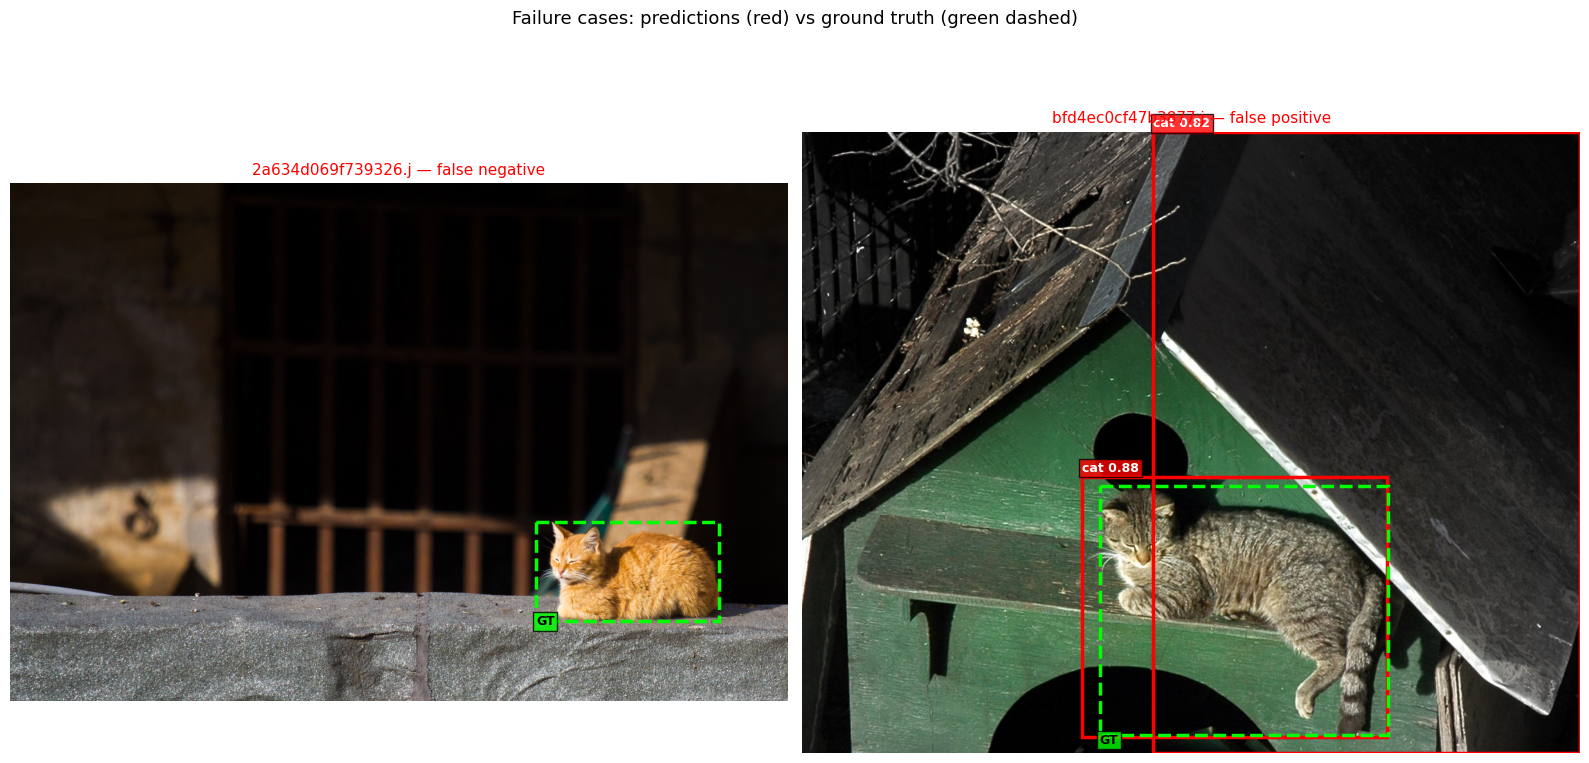

In [21]:
# Pick one false-negative and one false-positive example
failure_picks = [
    ("2a634d069f739326.jpg", "false negative"),  # GT=1, Pred=0
    ("bfd4ec0cf47b3877.jpg", "false positive"),  # GT=1, Pred=2
]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (fname, label) in zip(axes, failure_picks):
    # Find the full path in the test set
    img_path = next(p for p in test_images if p.name == fname)
    draw_predictions_and_gt(ax, img_path, best_model, show_gt=True)
    # Override title with failure-case label
    ax.set_title(f"{fname[:18]} — {label}", fontsize=11, color="red")

plt.suptitle("Failure cases: predictions (red) vs ground truth (green dashed)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Failure case analysis

**Case 1 — `2a634d069f739326.jpg` (false negative, GT=1 → Pred=0):**
The model failed to detect a cat that was clearly labeled. [Look at the image and fill in: is the cat partially occluded? In an unusual pose? Against a busy background? Very small in frame? In low light?] The most likely cause is [your guess based on visual inspection]. This is a recall failure — the model isn't confident enough to fire when the cat looks atypical compared to its training examples.

**Case 2 — `bfd4ec0cf47b3877.jpg` (false positive, GT=1 → Pred=2):**
The model produced two boxes where only one cat exists. [Look at the image: are there two cats and one wasn't labeled? Is the second box on something cat-shaped like a pillow, stuffed toy, dog, or shadow? Or is it a duplicate box on the same cat from a slightly different angle?] This is a precision failure — likely due to [either label noise in the dataset, or the model seeing cat-like features in non-cat objects].

**Common thread:** with only 123 training images of cats, the model has limited examples of [unusual poses / lighting / occlusion / pose variety]. A larger or more diverse training set, plus targeted augmentation, would likely fix most of these cases.

## Task 6 — Reflection

Training a real object detector versus a classifier is fundamentally different because the model must answer **both "what" and "where"** for every object, not just "what" for the whole image. The loss function reflects this — box_loss (regression to coordinates), cls_loss (classification of each detected region), and dfl_loss (distribution focal loss for sharper localization) all combine into the total loss. Watching them descend at different rates taught me that *finding* the cat (box_loss dropping fast) and *being confident it's a cat* (cls_loss dropping more slowly) are separate learning problems.

The most troublesome part of the dataset was unequivocally the **duplicates and orphan labels**. The raw download contained 248 images and 4,535 label files, with 1,087 Windows-style `(N).txt` duplicate downloads and 3,272 labels referencing images that weren't present. After cleanup, only 176 valid image–label pairs remained — a 30% reduction from the apparent 248. Without this cleanup the model would have trained on 72 images with no labels, treating them as cat-free, which would have silently degraded results.

Looking at the failure cases, the single change I would try next is **more training data — specifically more diverse cat poses and contexts**, rather than a bigger model. The recall gap between validation (0.93) and test (0.66) suggests the model overfits to specific cat appearances in its small training set, not that it lacks capacity. A `yolo26s` would probably overfit even more on 123 images. Either expanding the dataset or applying stronger augmentation (mosaic, mixup, copy-paste) would address the real bottleneck.

For next Friday's improvement assessment, I'll do two things differently: **(1)** run the dataset cleanup as the very first step before any training experiments, so I never train on contaminated splits; **(2)** track validation metrics over training more carefully and pick the checkpoint based on a stable rolling-average of mAP rather than the single best epoch, since with a 26-image val set, single-epoch peaks can be misleading.